# Dataset EDA


Data loaded from ../../../data/athens_ten_hours/athens_dump_output_10hour_training.csv with shape: (4830167, 6)
After dropping missing values: (3149976, 6)
Data sorted by 'timestep_time'.
Data loaded from ../../../data/athens_ten_hours/athens_dump_output_10hour_testing.csv with shape: (6133088, 6)
After dropping missing values: (4421605, 6)
Data sorted by 'timestep_time'.


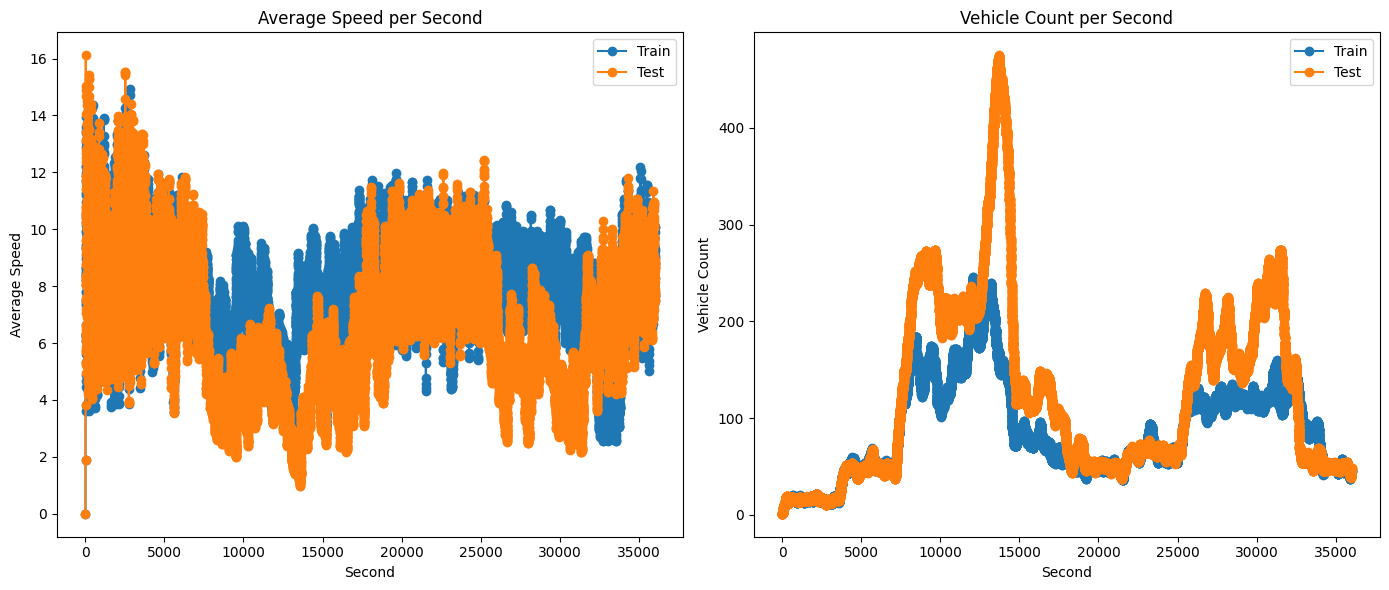

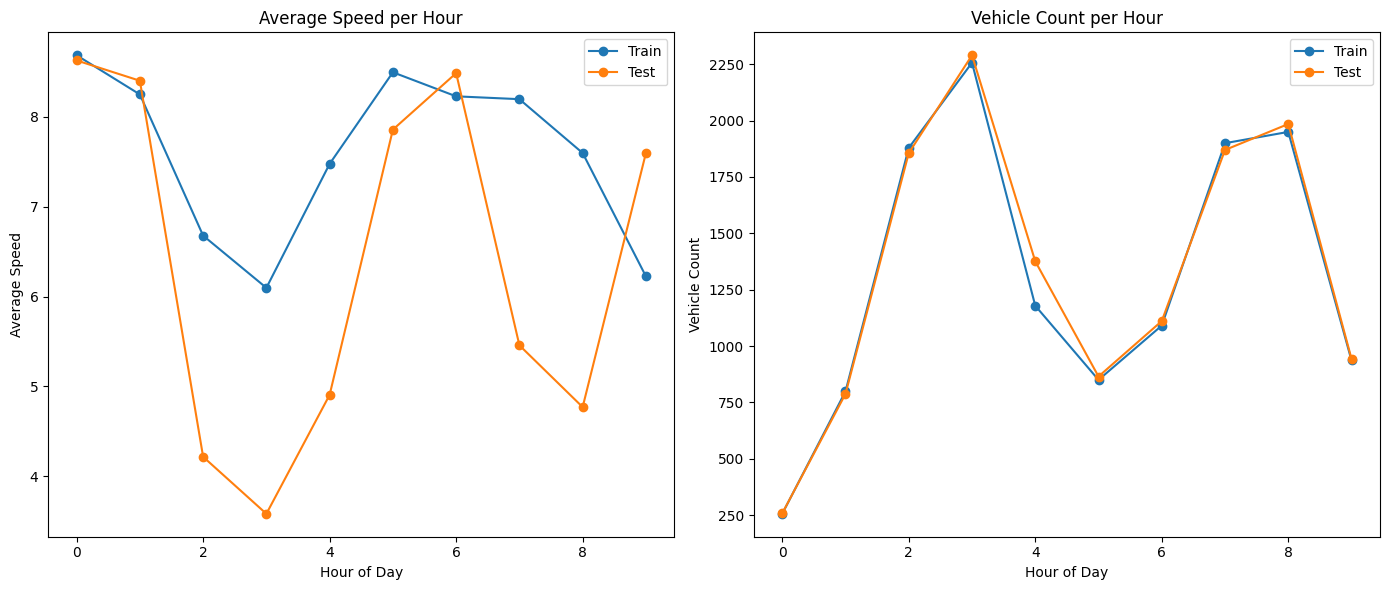

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def load_and_clean_data(file_path: str, delimiter: str = ";") -> pd.DataFrame:
    data = pd.read_csv(file_path, delimiter=delimiter)
    print(f"Data loaded from {file_path} with shape: {data.shape}")
    data = data.dropna()
    print(f"After dropping missing values: {data.shape}")
    data = data.sort_values("timestep_time").reset_index(drop=True)
    print("Data sorted by 'timestep_time'.")
    return data


def show_train_and_test_distribution(train_df: pd.DataFrame, test_df: pd.DataFrame):
    # Create per-hour column (if not present)
    if "hour_of_day" not in train_df.columns:
        train_df["hour_of_day"] = (train_df["timestep_time"] // 3600).astype(int)
    if "hour_of_day" not in test_df.columns:
        test_df["hour_of_day"] = (test_df["timestep_time"] // 3600).astype(int)

    # Create per-second column (if not present)
    if "second" not in train_df.columns:
        train_df["second"] = train_df["timestep_time"].astype(int)
    if "second" not in test_df.columns:
        test_df["second"] = test_df["timestep_time"].astype(int)

    # Group by second for per-second metrics: average speed and unique vehicle count
    train_secondly = (
        train_df.groupby("second")
        .agg({"vehicle_speed": "mean", "vehicle_id": "nunique"})
        .rename(columns={"vehicle_id": "vehicle_count"})
    )

    test_secondly = (
        test_df.groupby("second")
        .agg({"vehicle_speed": "mean", "vehicle_id": "nunique"})
        .rename(columns={"vehicle_id": "vehicle_count"})
    )

    # Group by hour for per-hour metrics: average speed and unique vehicle count
    train_hourly = (
        train_df.groupby("hour_of_day")
        .agg({"vehicle_speed": "mean", "vehicle_id": "nunique"})
        .rename(columns={"vehicle_id": "vehicle_count"})
    )

    test_hourly = (
        test_df.groupby("hour_of_day")
        .agg({"vehicle_speed": "mean", "vehicle_id": "nunique"})
        .rename(columns={"vehicle_id": "vehicle_count"})
    )

    # Plot per-second metrics
    plt.figure(figsize=(14, 6))

    # Subplot: Average speed per second
    plt.subplot(1, 2, 1)
    plt.plot(train_secondly.index, train_secondly["vehicle_speed"], marker="o", label="Train")
    plt.plot(test_secondly.index, test_secondly["vehicle_speed"], marker="o", label="Test")
    plt.title("Average Speed per Second")
    plt.xlabel("Second")
    plt.ylabel("Average Speed")
    plt.legend()

    # Subplot: Vehicle count per second
    plt.subplot(1, 2, 2)
    plt.plot(train_secondly.index, train_secondly["vehicle_count"], marker="o", label="Train")
    plt.plot(test_secondly.index, test_secondly["vehicle_count"], marker="o", label="Test")
    plt.title("Vehicle Count per Second")
    plt.xlabel("Second")
    plt.ylabel("Vehicle Count")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Plot per-hour metrics
    plt.figure(figsize=(14, 6))

    # Subplot: Average speed per hour
    plt.subplot(1, 2, 1)
    plt.plot(train_hourly.index, train_hourly["vehicle_speed"], marker="o", label="Train")
    plt.plot(test_hourly.index, test_hourly["vehicle_speed"], marker="o", label="Test")
    plt.title("Average Speed per Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Speed")
    plt.legend()

    # Subplot: Vehicle count per hour
    plt.subplot(1, 2, 2)
    plt.plot(train_hourly.index, train_hourly["vehicle_count"], marker="o", label="Train")
    plt.plot(test_hourly.index, test_hourly["vehicle_count"], marker="o", label="Test")
    plt.title("Vehicle Count per Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Vehicle Count")
    plt.legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Load and clean data from the CSV files
    train_data = load_and_clean_data(
        "../../../data/athens_ten_hours/athens_dump_output_10hour_training.csv", delimiter=";"
    )
    test_data = load_and_clean_data(
        "../../../data/athens_ten_hours/athens_dump_output_10hour_testing.csv", delimiter=";"
    )

    # Show the train and test distribution comparisons
    show_train_and_test_distribution(train_data, test_data)
